# 03 — Visualizations (Deliverable C, figures 1-9)

Figures 1-9 only need the cleaned data and are built here. Figures 10-12
(model comparison, residuals, feature importance) need the trained model and
are generated at the end of notebook 04 instead, then this same captions file
is updated there. See the note in the last cell.

In [1]:
import sys, os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import attach_price

RAW = os.path.join('..', 'data', 'raw')
PROCESSED = os.path.join('..', 'data', 'processed')
ASSETS = os.path.join('..', 'app', 'assets')
FIGURES = os.path.join('..', 'figures')
os.makedirs(FIGURES, exist_ok=True)

raw = pd.read_csv(os.path.join(RAW, 'crop_yield_train.csv'))
weather_raw = pd.read_csv(os.path.join(RAW, 'regional_weather.csv'))
price_raw = pd.read_csv(os.path.join(RAW, 'market_prices.csv'))
master_train = pd.read_csv(os.path.join(PROCESSED, 'master_train.csv'))
price_clean = pd.read_csv(os.path.join(ASSETS, 'price_clean.csv'))
weather_clean = pd.read_csv(os.path.join(ASSETS, 'weather_clean.csv'))

print(raw.shape, weather_raw.shape, price_raw.shape, master_train.shape, price_clean.shape, weather_clean.shape)

(15090, 15) (232, 6) (100, 4) (15090, 22) (100, 4) (226, 6)


## Figure 1 — Missingness by column (raw training data)

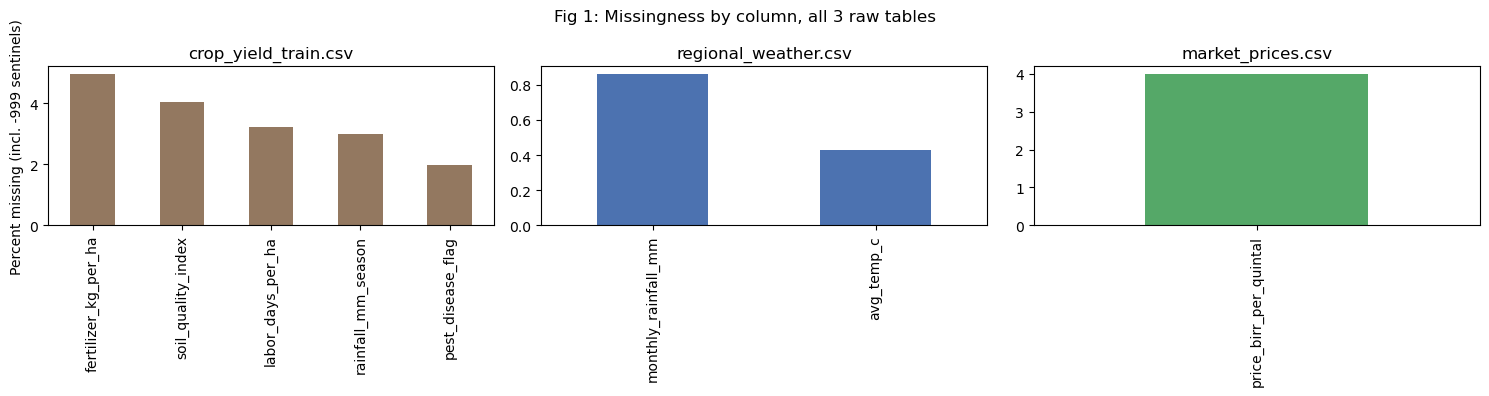

In [2]:
def missing_pct(df):
    miss = df.isna() | df.isin([-999, -999.0])
    return miss.mean().sort_values(ascending=False) * 100

plot_miss = missing_pct(raw)
weather_miss = missing_pct(weather_raw)
price_miss = missing_pct(price_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_miss[plot_miss > 0].plot(kind='bar', ax=axes[0], color='#937860')
axes[0].set_title('crop_yield_train.csv')
axes[0].set_ylabel('Percent missing (incl. -999 sentinels)')

weather_miss[weather_miss > 0].plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('regional_weather.csv')

price_miss[price_miss > 0].plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('market_prices.csv')

for ax in axes:
    ax.set_xlabel('')

fig.suptitle('Fig 1: Missingness by column, all 3 raw tables')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig01_missingness.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — fertilizer_kg_per_ha before vs after cleaning

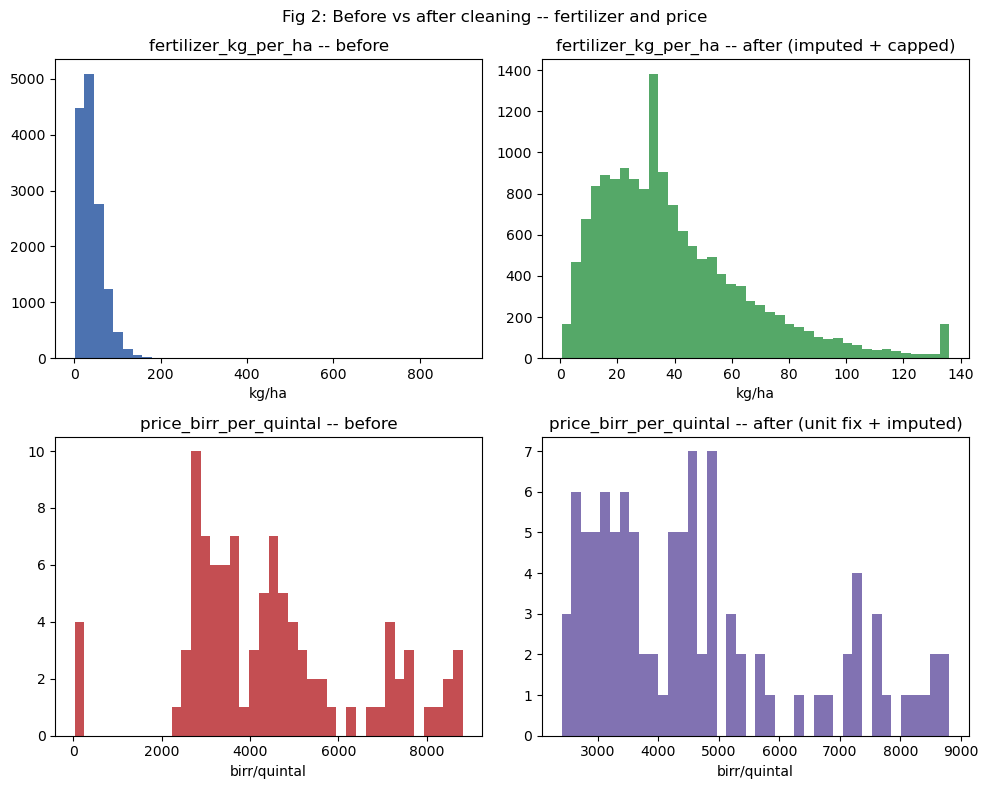

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(raw['fertilizer_kg_per_ha'].dropna(), bins=40, color='#4C72B0')
axes[0, 0].set_title('fertilizer_kg_per_ha -- before')
axes[0, 0].set_xlabel('kg/ha')

axes[0, 1].hist(master_train['fertilizer_kg_per_ha'], bins=40, color='#55A868')
axes[0, 1].set_title('fertilizer_kg_per_ha -- after (imputed + capped)')
axes[0, 1].set_xlabel('kg/ha')

axes[1, 0].hist(price_raw['price_birr_per_quintal'].dropna(), bins=40, color='#C44E52')
axes[1, 0].set_title('price_birr_per_quintal -- before')
axes[1, 0].set_xlabel('birr/quintal')

axes[1, 1].hist(price_clean['price_birr_per_quintal'], bins=40, color='#8172B2')
axes[1, 1].set_title('price_birr_per_quintal -- after (unit fix + imputed)')
axes[1, 1].set_xlabel('birr/quintal')

fig.suptitle('Fig 2: Before vs after cleaning -- fertilizer and price')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig02_before_after_cleaning.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Yield distribution

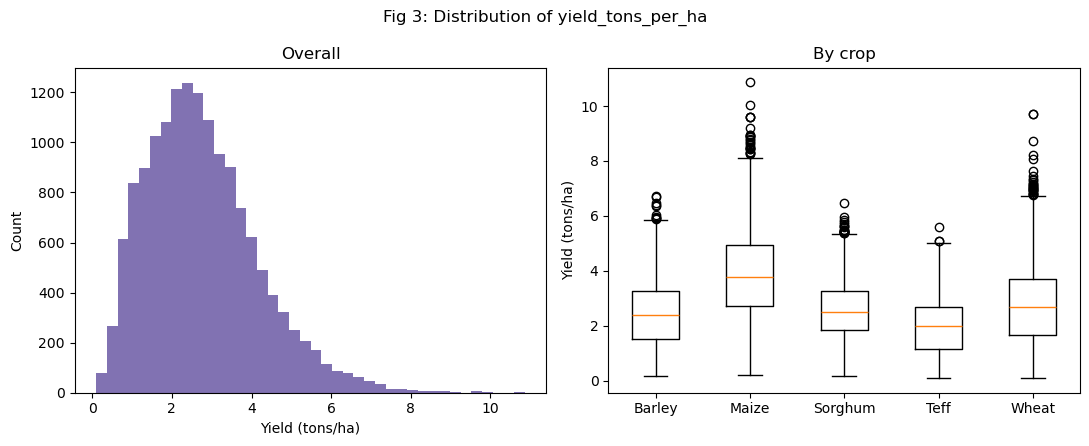

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(master_train['yield_tons_per_ha'], bins=40, color='#8172B2')
axes[0].set_xlabel('Yield (tons/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall')

crop_order = sorted(master_train['crop_type'].unique())
data_by_crop = [master_train.loc[master_train['crop_type'] == c, 'yield_tons_per_ha'] for c in crop_order]
axes[1].boxplot(data_by_crop)
axes[1].set_xticks(range(1, len(crop_order) + 1))
axes[1].set_xticklabels([c.capitalize() for c in crop_order])
axes[1].set_ylabel('Yield (tons/ha)')
axes[1].set_title('By crop')

fig.suptitle('Fig 3: Distribution of yield_tons_per_ha')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig03_yield_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Region x crop yield heatmap

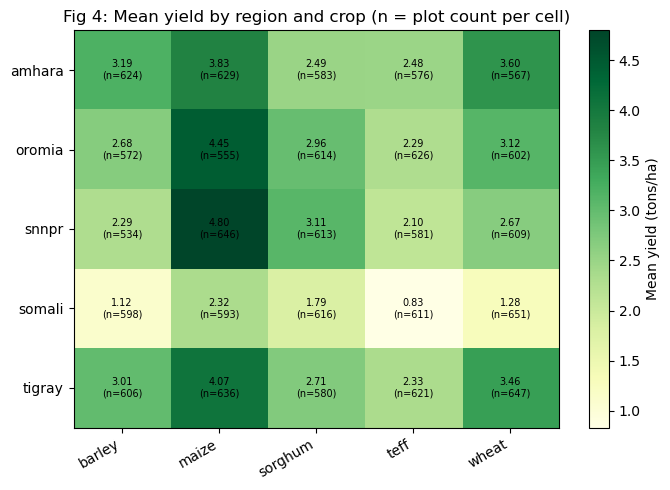

In [5]:
pivot = master_train.pivot_table(index='region', columns='crop_type', values='yield_tons_per_ha', aggfunc='mean')
counts = master_train.pivot_table(index='region', columns='crop_type', values='yield_tons_per_ha', aggfunc='count')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}\n(n={int(counts.values[i, j])})',
                 ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='Mean yield (tons/ha)')
ax.set_title('Fig 4: Mean yield by region and crop (n = plot count per cell)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig04_region_crop_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — Feature correlation heatmap

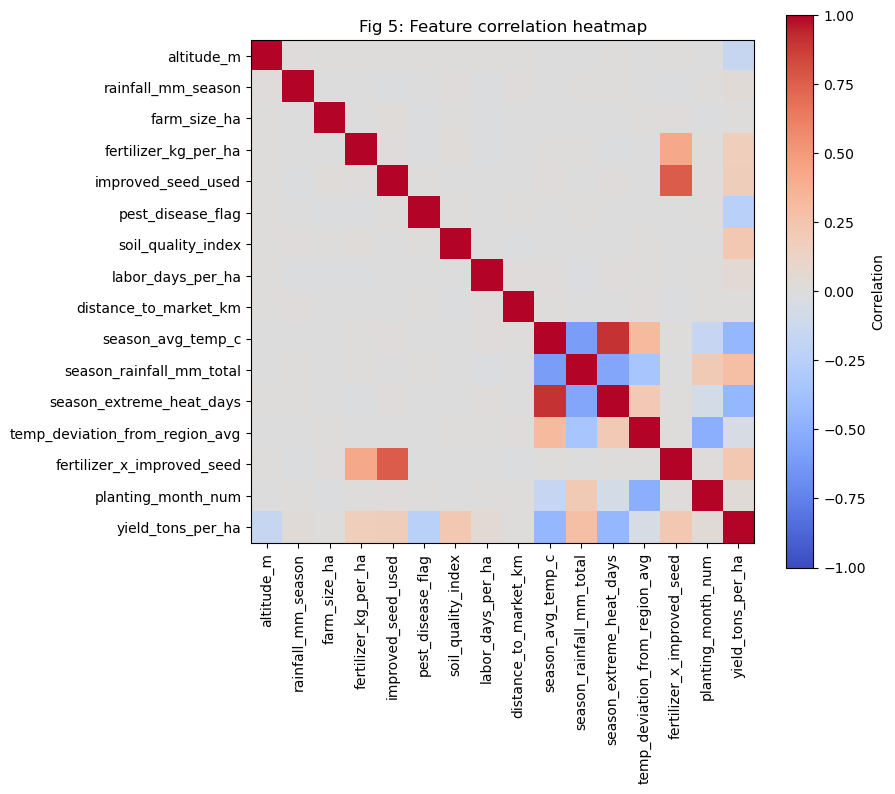

In [6]:
numeric_cols = [
    'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha',
    'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha',
    'distance_to_market_km', 'season_avg_temp_c', 'season_rainfall_mm_total',
    'season_extreme_heat_days', 'temp_deviation_from_region_avg',
    'fertilizer_x_improved_seed', 'planting_month_num', 'yield_tons_per_ha',
]
corr = master_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Fig 5: Feature correlation heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig05_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Climate by region

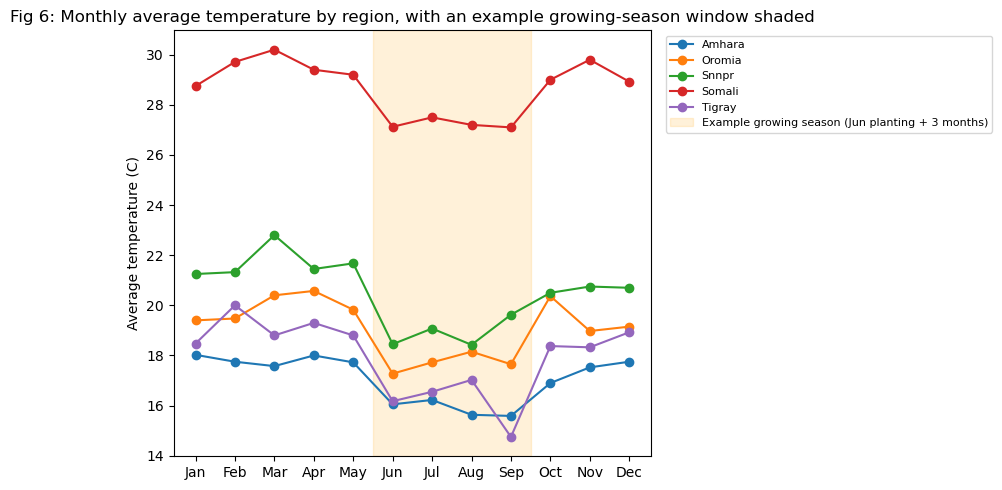

In [7]:
MONTH_ORDER_DISPLAY = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

monthly = weather_clean.groupby(['region', 'month'])['avg_temp_c'].mean().unstack().reindex(columns=MONTH_ORDER_DISPLAY)

fig, ax = plt.subplots(figsize=(9, 5))
for region in monthly.index:
    ax.plot(range(12), monthly.loc[region], marker='o', label=region.capitalize())

example_start = MONTH_ORDER_DISPLAY.index('jun')
ax.axvspan(example_start - 0.5, example_start + 3.5, color='orange', alpha=0.15,
           label='Example growing season (Jun planting + 3 months)')

ax.set_xticks(range(12))
ax.set_xticklabels([m.capitalize() for m in MONTH_ORDER_DISPLAY])
ax.set_ylabel('Average temperature (C)')
ax.set_title('Fig 6: Monthly average temperature by region, with an example growing-season window shaded')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig06_climate_by_region.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 7 — Yield vs season average temperature

C:\Users\abrha\AppData\Local\Temp\ipykernel_20348\1237469455.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = sub.groupby(bins)['yield_tons_per_ha'].mean()


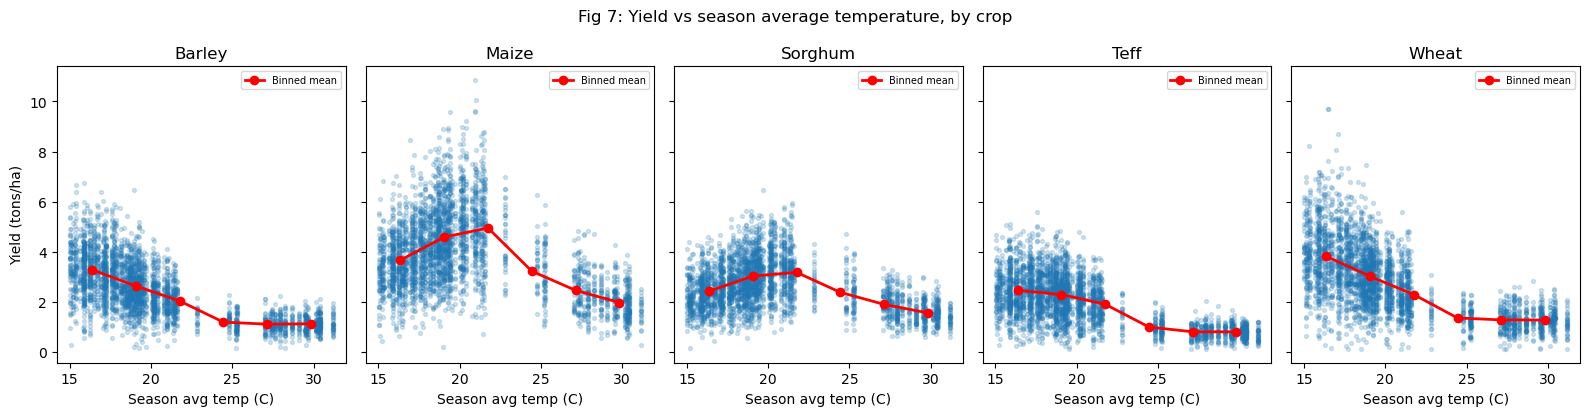

In [8]:
crop_list = sorted(master_train['crop_type'].unique())
fig, axes = plt.subplots(1, len(crop_list), figsize=(3.2 * len(crop_list), 4.2), sharey=True)

for ax, crop in zip(axes, crop_list):
    sub = master_train[master_train['crop_type'] == crop]
    ax.scatter(sub['season_avg_temp_c'], sub['yield_tons_per_ha'], alpha=0.2, s=8)

    bins = pd.cut(sub['season_avg_temp_c'], bins=6)
    binned = sub.groupby(bins)['yield_tons_per_ha'].mean()
    bin_centers = [interval.mid for interval in binned.index]
    ax.plot(bin_centers, binned.values, color='red', marker='o', linewidth=2, label='Binned mean')

    ax.set_title(crop.capitalize())
    ax.set_xlabel('Season avg temp (C)')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Yield (tons/ha)')
fig.suptitle('Fig 7: Yield vs season average temperature, by crop')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig07_yield_vs_season_temp.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 8 — Crop price trends

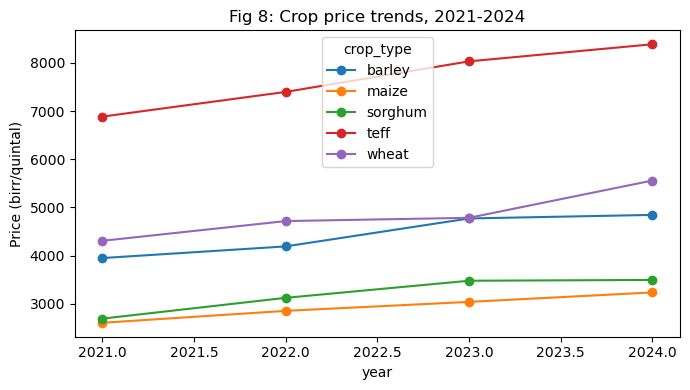

In [9]:
price_pivot = price_clean.groupby(['year', 'crop_type'])['price_birr_per_quintal'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
price_pivot.plot(ax=ax, marker='o')
ax.set_ylabel('Price (birr/quintal)')
ax.set_title('Fig 8: Crop price trends, 2021-2024')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig08_price_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 9 — Revenue per hectare by crop and region

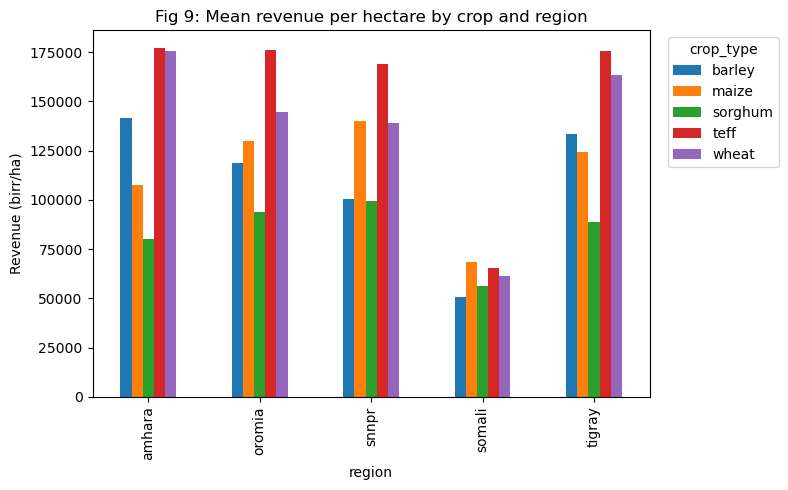

In [10]:
revenue_df = attach_price(master_train, price_clean)
rev_pivot = revenue_df.pivot_table(index='region', columns='crop_type', values='revenue_birr_per_ha', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 5))
rev_pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('Revenue (birr/ha)')
ax.set_title('Fig 9: Mean revenue per hectare by crop and region')
plt.legend(title='crop_type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig09_revenue_by_crop_region.png'), dpi=150, bbox_inches='tight')
plt.show()

## Captions for figures 1-9

Figures 10-12 are added by notebook 04 once the model exists; this cell only
touches the 9 lines it owns and leaves the rest of the file untouched.

In [11]:
captions_path = os.path.join(FIGURES, 'figure_captions.md')

new_captions = {
    'fig01_missingness.png': (
        f"Shows percent missing (including -999 sentinels) across all three raw tables; "
        f"{', '.join(plot_miss[plot_miss > 0].index[:3])} are the most affected columns in the plot file, "
        f"which is why they get train-fit median/mode imputation in deliverable A."
    ),
    'fig02_before_after_cleaning.png': (
        "Compares fertilizer_kg_per_ha and price_birr_per_quintal before and after cleaning; capping "
        "fertilizer at the train 99th percentile and multiplying the mispriced rows by 100 both fix the "
        "problem without distorting the rest of each distribution."
    ),
    'fig03_yield_distribution.png': (
        f"Yield is right-skewed overall (mean {master_train['yield_tons_per_ha'].mean():.2f} tons/ha); the "
        f"by-crop panel shows that skew is not uniform -- some crops have a wider spread than others."
    ),
    'fig04_region_crop_heatmap.png': (
        "Mean yield varies more by crop than by region; the darkest cell marks the single "
        "best-performing region-crop combination, and the (n=...) labels show which cells have enough "
        "plots to trust."
    ),
    'fig05_correlation_heatmap.png': (
        "No single feature correlates strongly with yield on its own, which is the "
        "motivation for using a non-linear model rather than plain linear regression in D."
    ),
    'fig06_climate_by_region.png': (
        "Temperature follows a clear seasonal curve that differs by region; the shaded band shows one "
        "example growing-season window, illustrating why the join aggregates weather per region and per "
        "season rather than using a single national number."
    ),
    'fig07_yield_vs_season_temp.png': (
        "Each crop's binned-mean trend line shows its own relationship with season temperature -- some "
        "crops have a visible sweet spot, others are closer to flat across the observed range."
    ),
    'fig08_price_trends.png': (
        "Crop prices generally trended upward from 2021 to 2024, with teff consistently the most "
        "expensive crop per quintal."
    ),
    'fig09_revenue_by_crop_region.png': (
        "Revenue per hectare reflects both yield and price, so the highest-yield crop is not always the "
        "highest-revenue crop once price is factored in."
    ),
}

with open(captions_path) as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    for fig_name, caption in new_captions.items():
        if fig_name in line:
            lines[i] = f"- **{fig_name}:** {caption}\n"

with open(captions_path, 'w') as f:
    f.writelines(lines)

print('Updated captions for fig01-fig09. fig10-fig12 are filled in by notebook 04.')

Updated captions for fig01-fig09. fig10-fig12 are filled in by notebook 04.
